## Układ i parametry symulacji

### Warunek początkowy
Symulacja startuje ze stanu spoczynkowego. Swobodna powierzchnia wody jest początkowo płaska:
- ζ(0) = 0, więc nie ma początkowej fali.    
- Wysokość słupa wody jest równa barymetri początkowej:$h(x,y,0)=H_0(x,y)$, co oznacza, że mamy spokojny zbiornik wodny na którym nie ma
  żadnych fal  
- Pędy początkowe:   
  $uh(x,y,0)=0,\quad vh(x,y,0)=0,$   
  co odpowiada zerowym prędkościom $u=v=0$, inaczej mówiąc woda jest w spoczynku.   

### Batymetria (dno) i jej zmienność w czasie
Początkowo zbiornik ma liniowy opad do dna, co reprezentuje brzeg i następnie jest dno o głębokości 1.0.

**Batymetria początkowa `H0`:**
Warunek początkowy dla czasu t=0 rozważa okład z linowo opadającym brzegiem do powenego poziomu, po którym głębokość jest stała:   
- Domeną symulacji jest siatka o rozmiarze `grid = (50, 40)` komórek.   
- Głębokość rośnie liniowo w kierunku osi `y` od brzegu (y=0) do części głębokiej:
  - maksymalna głębokość: `max_depth = 1.0`,   
  - długość stoku: `slope_length = ny//2 = 20` komórek.
- Profil 1D:   
  $$
  H_0(y)=\text{max\_depth}\cdot \min(y, \text{slope\_length})/\text{slope\_length},
  $$
  następnie powielony w osi `x`, więc stok jest jednorodny wzdłuż brzegu.

**Deformacja dna w czasie:**
  Symulowane będzie osuwisko części dna w centrum analizowanej siatki, oraz jak prędkośc tego osuwania wpływa na powstałe w ten sposób fale.    
  Aby tego dokonać:   
- Zadany jest „garb” (`bump_shape`) w centrum siatki, który jest kwadratem  ok. $nx/10 \times ny/10$ komórek,
  o amplitudzie zmiany głębokości `0.5`.
- Narastanie w czasie jest gładkie (półkosinus) w przedziale $0 \le t \le T_{\text{rise}}$:
  - `T_rise = 5.0` oraz `T_rise=10.0`,
  $$
  \alpha(t)=\tfrac12\left[1-\cos\left(\pi t/T_{\text{rise}}\right)\right],
  $$
  a po tym czasie $\alpha=1$.
- Batymetria w czasie:
  $$
  b(x,y,t)=H_0(x,y)-\alpha(t)\,\text{bump\_shape}(x,y).
  $$
- Zmiana dna sprzężona jest z równaniem ciągłości przez jawny człon źródłowy:
  $$
  h^{n+1}=h^{n}-\Delta b,
  $$
  co odpowiada $\partial_t h = -\partial_t b$.

### Siatka i parametry numeryczne
- Siatka: `nx = 50`, `ny = 40`.
- Kroki przestrzenne przyjęte jednostkowe: $\Delta x=\Delta y=1$.
- Krok czasowy: `dt = 0.02`.
- Liczba kroków czasowych: `nt = 600`,
- Współczynniki CFL liczone osobno w osiach x i y, z warunkiem stabilności $|C|\le 1$.
- Warunki brzegowe: stała wartość zero w halo (`Constant(value=0)`), czyli twarde warunki Dirichleta dla `h, uh, vh`.

### Parametry fizyczne
- Przyspieszenie grawitacyjne: `g = 10`.
- Brak tarcia dna, lepkości i wymuszeń zewnętrznych (fala powstaje wyłącznie od deformacji dna i siły grawitacji).


### Pytanie badawcze: 
##### Jak czasowa i przestrzenna zmienność dna morskiego wpływa na powstawanie oraz charakterystykę propagacji fal w modelu opisywanym przez shallow water equations?

Aby odpowiedzieć na to pytanie 2 wartości parametrów zostaną zbadane, `T_rise = 5.0` oraz `T_rise = 10.0`, co odpowiada szybszemu i wolniejszemu tępu osuwania się dna.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')

In [2]:
pip install PyMPDATA


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /home/pawel/ml/my_env/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 0. potrzebne pakiety Pythona

In [3]:
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

### 2. solwer "hello-world" zbudowany na bazie PyMPDATA

In [5]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray,bathymetry: np.ndarray = None , bathymetry_updater = None, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)

        self.bathymetry = bathymetry.copy() if bathymetry is not None else None

        self.bathymetry_updater = bathymetry_updater
        
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        output['bathymetry'] = []  # NEW
    
        for it in range(nt + 1):
            # --- time-dependent bathymetry ---
            if self.bathymetry_updater is not None:
                old_b = self.bathymetry.copy()
                new_b = self.bathymetry_updater(it, self.bathymetry)
                if new_b is not None:
                    self.bathymetry[...] = new_b
                # continuity source: dh/dt = - d(bathymetry)/dt
                delta_b = self.bathymetry - old_b   # this is ΔH over one step
                self['h'][:] -= delta_b             # explicit Euler for the source term
            # ---------------------------------
    
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
    
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
                output['bathymetry'].append(self.bathymetry.copy())  # NEW
    
        return output


In [6]:
def bathymetry_updater(it, current_b):
    t = it * dt
    # smooth 0 -> 1 ramp over [0, T_rise] using half-cosine
    if t <= T_rise:
        alpha = 0.5 * (1 - np.cos(np.pi * t / T_rise))
    else:
        alpha = 1.0
    # update in-place: H(t) = H0 + alpha * bump_shape
    current_b[...] = H0 + alpha * bump_shape
    # return None to signal "updated in-place"
    return None

### 3. symulacja dla dt=0.02 oraz T_rise = 5.0

In [7]:
dt = 0.02 # consistent with your dt_over_dxy
#Aby zmienić szybkość deformacji, to zmieniasz to (wczescniej było 10):
T_rise = 5.0  # physical time for the bottom deformation


grid = (50, 40)
nx, ny = grid

max_depth = 1.0       # depth offshore
slope_length = ny//2  # number of grid cells over which depth increases linearly

# y index: 0 ... ny-1
y = np.arange(ny)

# linear profile: depth goes from 0 at shore (y=0) to max_depth at y = slope_length
depth_profile = max_depth * np.minimum(y, slope_length) / slope_length   # shape (ny,)

# make it 2D: same along x
H0 = np.tile(depth_profile, (nx, 1))   # shape (nx, ny)


# bump shape that will grow in time (sea-floor uplift)
bump_shape = np.zeros(grid)
bump_shape[
    grid[0] // 2 - grid[0] // 20:
    grid[0] // 2 + grid[0] // 20,
    grid[1] // 2 - grid[1] // 20:
    grid[1] // 2 + grid[1] // 20
] = 0.5   # amplitude of depth *change* (you can tune this)

zeta0 = np.zeros(grid)             # free-surface perturbation
h_initial = H0 + zeta0             # = H0, still water


integrator = ShallowWaterEquationsIntegrator(
    h_initial=h_initial,
    bathymetry=H0,
    bathymetry_updater=bathymetry_updater
)

dt_over_dxy = (dt, dt)  # assuming Δx = Δy = 1
output1 = integrator(
    nt=600,
    g=10,
    dt_over_dxy=dt_over_dxy,
    outfreq=(outfreq := 3)
)


/home/pawel/ml/my_env/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


### 4. Wizualizacja

In [8]:
dt = 0.02 # consistent with your dt_over_dxy
#Aby zmienić szybkość deformacji, to zmieniasz to (wczescniej było 10):
T_rise = 10.0  # physical time for the bottom deformation


grid = (50, 40)
nx, ny = grid

max_depth = 1.0       # depth offshore
slope_length = ny//2  # number of grid cells over which depth increases linearly

# y index: 0 ... ny-1
y = np.arange(ny)

# linear profile: depth goes from 0 at shore (y=0) to max_depth at y = slope_length
depth_profile = max_depth * np.minimum(y, slope_length) / slope_length   # shape (ny,)

# make it 2D: same along x
H0 = np.tile(depth_profile, (nx, 1))   # shape (nx, ny)


# bump shape that will grow in time (sea-floor uplift)
bump_shape = np.zeros(grid)
bump_shape[
    grid[0] // 2 - grid[0] // 20:
    grid[0] // 2 + grid[0] // 20,
    grid[1] // 2 - grid[1] // 20:
    grid[1] // 2 + grid[1] // 20
] = 0.5   # amplitude of depth *change* (you can tune this)

zeta0 = np.zeros(grid)             # free-surface perturbation
h_initial = H0 + zeta0             # = H0, still water


integrator = ShallowWaterEquationsIntegrator(
    h_initial=h_initial,
    bathymetry=H0,
    bathymetry_updater=bathymetry_updater
)

dt_over_dxy = (dt, dt)  # assuming Δx = Δy = 1
output2 = integrator(
    nt=600,
    g=10,
    dt_over_dxy=dt_over_dxy,
    outfreq=(outfreq := 3)
)


In [9]:
from pint import UnitRegistry
si = UnitRegistry()

In [10]:
def compute_velocity(h, uh, vh, eps=1e-7):
    """Z pędu (uh, vh) i głębokości h zwraca (u, v), z maską dla prawie suchych komórek."""
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    wet = h > eps
    u[wet] = uh[wet] / h[wet]
    v[wet] = vh[wet] / h[wet]
    return u, v, wet


In [30]:
# case parameters
dt1 = 0.02      # for output1
dt2 = 0.02      # for output2

frame1 = 200     # frame from output1
frame2 = 200    # frame from output2

outfreq = 3     # same as used in your integrator()


# ===== CASE 1 =====
h1  = output1['h'][frame1]
uh1 = output1['uh'][frame1]
vh1 = output1['vh'][frame1]
H1  = output1['bathymetry'][frame1]

eta1 = h1 - H1
u1, v1, wet1 = compute_velocity(h1, uh1, vh1)

nx, ny = h1.shape
x, y = np.meshgrid(np.arange(ny), np.arange(nx))

t1_phys = frame1 * outfreq * dt1


# ===== CASE 2 =====
h2  = output2['h'][frame2]
uh2 = output2['uh'][frame2]
vh2 = output2['vh'][frame2]
H2  = output2['bathymetry'][frame2]

eta2 = h2 - H2
u2, v2, wet2 = compute_velocity(h2, uh2, vh2)

t2_phys = frame2 * outfreq * dt2


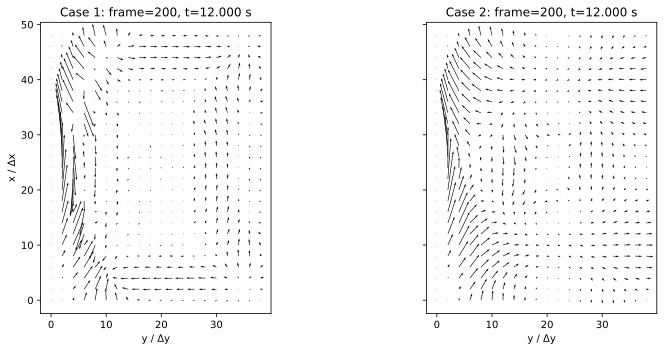

In [31]:
# ===== PLOT BOTH NEXT TO EACH OTHER =====
fig, axes = pyplot.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

step = 2  # downsample vectors


# LEFT PLOT – CASE 1
ax = axes[0]
ax.quiver(
    x[::step, ::step], y[::step, ::step],
    u1[::step, ::step], v1[::step, ::step],
    angles='xy', scale_units='xy', scale=None
)
ax.set_title(f'Case 1: frame={frame1}, t={t1_phys:.3f} s')
ax.set_xlabel('y / Δy')
ax.set_ylabel('x / Δx')
ax.set_aspect('equal')


# RIGHT PLOT – CASE 2
ax = axes[1]
ax.quiver(
    x[::step, ::step], y[::step, ::step],
    u2[::step, ::step], v2[::step, ::step],
    angles='xy', scale_units='xy', scale=None
)
ax.set_title(f'Case 2: frame={frame2}, t={t2_phys:.3f} s')
ax.set_xlabel('y / Δy')
ax.set_aspect('equal')


pyplot.tight_layout()
pyplot.savefig('velocity_cases_side_by_side.pdf', bbox_inches='tight')
pyplot.show()


/tmp/ipykernel_237590/2695928502.py:31: UserWarning: Adding colorbar to a different Figure <Figure size 1500x500 with 3 Axes> than <Figure size 1200x500 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(c1, ax=axes, label=r'$\eta$', shrink=0.82)


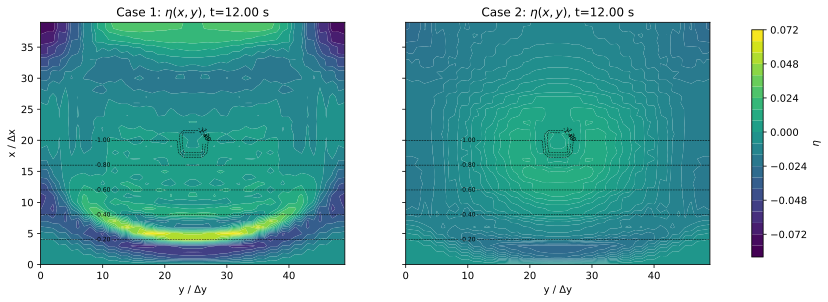

In [32]:
ig, axes = pyplot.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

# shared color scale
vmin = min(eta1.min(), eta2.min())
vmax = max(eta1.max(), eta2.max())
levels = 20


# -------- CASE 1 PANEL --------
ax = axes[0]
c1 = ax.contourf(y, x, eta1, levels=levels, vmin=vmin, vmax=vmax)
cs1 = ax.contour(y, x, -H1, colors='k', linewidths=0.5)
ax.clabel(cs1, inline=True, fontsize=6, fmt='%.2f')
ax.set_title(rf'Case 1: $\eta(x,y)$, t={t1_phys:.2f} s')
ax.set_xlabel('y / Δy')
ax.set_ylabel('x / Δx')
ax.set_aspect('equal')


# -------- CASE 2 PANEL --------
ax = axes[1]
c2 = ax.contourf(y, x, eta2, levels=levels, vmin=vmin, vmax=vmax)
cs2 = ax.contour(y, x, -H2, colors='k', linewidths=0.5)
ax.clabel(cs2, inline=True, fontsize=6, fmt='%.2f')
ax.set_title(rf'Case 2: $\eta(x,y)$, t={t2_phys:.2f} s')
ax.set_xlabel('y / Δy')
ax.set_aspect('equal')


# -------- ONE SHARED COLORBAR --------
fig.colorbar(c1, ax=axes, label=r'$\eta$', shrink=0.82)

#pyplot.tight_layout()
pyplot.savefig('eta_cases_side_by_side.pdf', bbox_inches='tight')
pyplot.show()



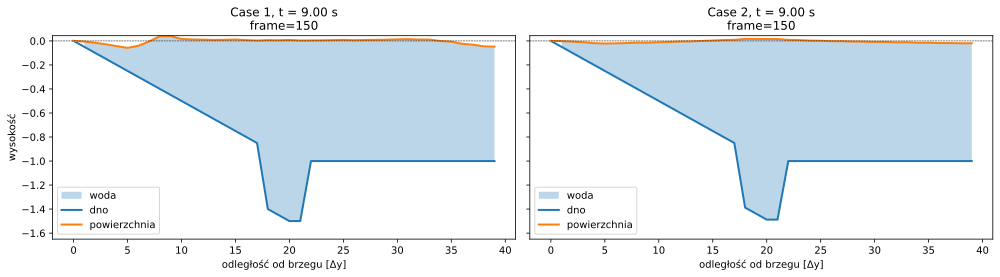

In [26]:


dt1 = 0.02
dt2 = 0.02
outfreq = 3


# ------------------------------------------------------------
# extract case 1
h1  = output1['h'][frame1]
H1  = output1['bathymetry'][frame1]
eta1 = h1 - H1

nx1, ny1 = h1.shape
x0_1 = nx1 // 2

dy = 1.0
s1 = np.arange(ny1) * dy

bottom1  = -H1[x0_1, :]
surface1 = eta1[x0_1, :]

t1_phys = frame1 * outfreq * dt1


# ------------------------------------------------------------
# extract case 2
h2  = output2['h'][frame2]
H2  = output2['bathymetry'][frame2]
eta2 = h2 - H2

nx2, ny2 = h2.shape
x0_2 = nx2 // 2

s2 = np.arange(ny2) * dy

bottom2  = -H2[x0_2, :]
surface2 = eta2[x0_2, :]

t2_phys = frame2 * outfreq * dt2


# ------------------------------------------------------------
# make figure with two subplots
fig, axes = pyplot.subplots(1, 2, figsize=(14, 4), sharey=True)


# ------------------------------------------------------------
# LEFT PANEL: case 1
ax = axes[0]

ax.fill_between(s1, bottom1, surface1,
                where=surface1 > bottom1,
                alpha=0.3, label='woda')

ax.plot(s1, bottom1,  lw=2, label='dno')
ax.plot(s1, surface1, lw=2, label='powierzchnia')

ax.set_title(f'Case 1, t = {t1_phys:.2f} s\nframe={frame1}')
ax.set_xlabel('odległość od brzegu [Δy]')
ax.set_ylabel('wysokość')
ax.axhline(0.0, color='k', lw=0.5, linestyle='--')
ax.legend(loc='best')
ax.set_ylim(min(bottom1.min(), bottom2.min()) * 1.1,
            max(surface1.max(), surface2.max(), 0) * 1.1)


# ------------------------------------------------------------
# RIGHT PANEL: case 2
ax = axes[1]

ax.fill_between(s2, bottom2, surface2,
                where=surface2 > bottom2,
                alpha=0.3, label='woda')

ax.plot(s2, bottom2,  lw=2, label='dno')
ax.plot(s2, surface2, lw=2, label='powierzchnia')

ax.set_title(f'Case 2, t = {t2_phys:.2f} s\nframe={frame2}')
ax.set_xlabel('odległość od brzegu [Δy]')
ax.axhline(0.0, color='k', lw=0.5, linestyle='--')
ax.legend(loc='best')


pyplot.tight_layout()
pyplot.savefig(f'przekroj_cases_side_by_side.pdf', bbox_inches='tight')
pyplot.show()

## Wnioski

Z symulacji wynika, że fala dotrze do brzegu w mniej więcej tym samym czasie dla obu badanych przypadków, pole wektrorowe
prędkości wody natomiast jest różne.   
Jeśli chodzi o amplitudę fali wodnej:    
 - W przypadku, gdy prędkość opadania jest szybsza (`T_rise=10.0`) fale przy brzegu mają zdecydowanie większą amplitudę niż
   w przypadku z opadaniem wolniejszym.
Fale również sprzężają się bardziej po stronie brzegu, natomiast tam gdzie dno jest płaskie fala zagina się w dół i nie
ma zaobserwowanego spiętrzenia fali większego niż średni poziom wody.
 